In [1]:
import pandas as pd
import nltk 
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk import RegexpParser
from nltk.tokenize import sent_tokenize
from nltk import Tree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from transformers import TFBertModel, AutoTokenizer
from transformers import logging
from scipy.spatial.distance import cosine
from concurrent.futures import ProcessPoolExecutor
import warnings
import time
from concurrent.futures import ThreadPoolExecutor
import math
# import openai
from transformers import logging
import torch
from sentence_transformers import SentenceTransformer
# import pyphen
from collections import Counter
from collections import defaultdict
from joblib import Parallel, delayed
from scipy.optimize import curve_fit
import itertools
from scipy.special import comb
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings('ignore')
logging.set_verbosity_error()  # disable warnings from transformer, hugging face package.

## Data Processing for all the stories to get the pos-tagged phrases. 

In [2]:
## get all the stories.  nine stories in total.
story_all = [] 

data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/boyscout.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v1-pool.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v2-lake.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v1-rookie.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v2-catlady.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/panic.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v1-park.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v2-church.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/stein.pkl")
story_all.append(data)

cleaned_all = []
for index in np.arange(len(story_all)):
    cleaned_data = {key: [str(value) for value in val] for key, val in story_all[index].items()}
    cleaned_all.append(cleaned_data)

## get narrative and recalls from the data.
def fetch_text(input_dic):
    story = "".join(input_dic['narrative'])
    recall = input_dic['recalls']
    return story, recall

story_all, recall_all = zip(*[fetch_text(data) for data in cleaned_all])

In [3]:
## three more stories added to the analysis.
story_additional = [] 
recall_additional = []

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-segments.csv", encoding='utf-8')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-recalls_segmented.csv", encoding='utf-8')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/do-something-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/dosomething-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

additional_story_processed = []
additional_recall_processed = [[] for _ in np.arange(3)]
score_processed_additional = []

for i in np.arange(3):
    # the original story in segment.
    story = story_additional[i]['segment_text']
    story_as_list = story.tolist()
    additional_story_processed.append(story_as_list)

    # get the recall text by each participant.
    recall = recall_additional[i]
    recall_id = recall['recall_id']
    recall_id_set = list(set(recall_id))
    for j in recall_id_set:
        recall_participant = recall[recall['recall_id'] == j]
        recall_content = recall_participant['clause_text']
        recall_as_list = recall_content.tolist()
        additional_recall_processed[i].append(recall_as_list)


In [4]:
additional_story_processed = [' '.join(sublist) for sublist in additional_story_processed]
additional_recall_processed = [[' '.join(additional_recall_processed[story][participant]) for participant in np.arange(len(additional_recall_processed[story]))]
                                for story in np.arange(len(additional_recall_processed))]

## add the new data to the dataset.
story_all = story_all + tuple(additional_story_processed)
recall_all = recall_all + tuple(additional_recall_processed)


## Process the data to get phrases.

In [5]:
import re
from nltk import sent_tokenize, word_tokenize, pos_tag, RegexpParser

# ── text preprocessing ────────────────────────────────────────────────────────
def pre_processing_text(input_text):
    sentences = sent_tokenize(input_text)
    tokens    = [word_tokenize(s) for s in sentences]
    return [
        [w.lower() for w in sentence if re.match(r'^\w+$', w)]
        for sentence in tokens
    ]

story_processed_all  = [pre_processing_text(s) for s in story_all]
recall_processed_all = [[pre_processing_text(r) for r in story] for story in recall_all]

# ── POS tagging ───────────────────────────────────────────────────────────────
def get_part_of_speech(sentences):
    return [pos_tag(s) for s in sentences]

tagged_all        = [get_part_of_speech(s) for s in story_processed_all]
tagged_recall_all = [[get_part_of_speech(r) for r in story] for story in recall_processed_all]

# ── noun phrase extraction ────────────────────────────────────────────────────
NP_GRAMMAR  = "NP: {<DT>?<CD>?<JJ>*<NN.*>+}"
NP_PARSER   = RegexpParser(NP_GRAMMAR)

def find_noun_phrase(tagged_sentences):
    trees = [NP_PARSER.parse(s) for s in tagged_sentences]
    return [sub for tree in trees for sub in tree.subtrees() if sub.label() == 'NP']

noun_all        = [find_noun_phrase(t) for t in tagged_all]
noun_recall_all = [[find_noun_phrase(r) for r in story] for story in tagged_recall_all]


### fetch subtypes of noun phrases. and calculate together with general noun types.

In [6]:
import spacy
nlp = spacy.load('en_core_web_sm')

# dependency label → role name
role_map = {
    'nsubj':    'subject',
    'nsubjpass':'subject (passive)',
    'dobj':     'direct object',
    'iobj':     'indirect object',
    'pobj':     'prepositional object',
    'attr':     'attribute',
}

noun_roles_all = []

for s, story in enumerate(story_all):
    doc = nlp(story)
    by_role = defaultdict(list)

    for token in doc:
        if token.pos_ in ('NOUN', 'PROPN') and token.dep_ in role_map:
            role = role_map[token.dep_]
            # get the full noun phrase this token heads
            np_text = ' '.join(t.text for t in token.subtree)
            by_role[role].append(np_text)

    noun_roles_all.append(dict(by_role))

    print(f"\nStory {s+1}")
    for role, phrases in sorted(by_role.items()):
        print(f"  {role} ({len(phrases)}): {phrases[:3]}")



Story 1
  attribute (1): ['another guy , who had just walked up that minute']
  direct object (5): ['the 50 - yard dash , racing', 'the 50 - yard dash', 'cramps']
  prepositional object (4): ['the boy', 'the time', 'the pier']
  subject (2): ['the fellows', 'Scoutmaster']

Story 2
  direct object (4): ['a bee hovering near my face', 'a glass of champagne', 'things']
  prepositional object (8): ['the pool', "my cousin 's wedding reception , where everyone was dressed to impress", 'my face']
  subject (5): ['  My best friend', 'my aunt', "' Course friends , y'know"]
  subject (passive) (1): ['my beautiful dress']

Story 3
  attribute (1): ['a frog on the shore']
  direct object (5): ['a peaceful afternoon', "a frog near the water 's edge", 'my sandwich']
  prepositional object (8): ['the lake', 'our annual summer camping trip', "the water 's edge"]
  subject (3): ['  My best friend', "' Course friends , y'know", 'the first thing to do']

Story 4
  attribute (7): ['a rookie in the police

In [7]:
from sentence_transformers import SentenceTransformer
import numpy as np

model    = SentenceTransformer('all-MiniLM-L6-v2')
EMB_DIM  = 384

# ── clean noun phrase trees → text ───────────────────────────────────────────
def clean_tree(input_tree):
    seen, unique = set(), []
    for node in input_tree:
        p = " ".join(word for word, tag in node.leaves())
        if p not in seen and p.lower() != "i":
            seen.add(p)
            unique.append(p)
    return unique

cleaned_np_all        = [clean_tree(np) for np in noun_all]
cleaned_np_recall_all = [[clean_tree(r) for r in story] for story in noun_recall_all]

# ── embed recall NPs ──────────────────────────────────────────────────────────
def embed_np_list(np_list):
    return np.array(model.encode(np_list)) if np_list else np.zeros((0, EMB_DIM))

np_recall_emb_all = []
for s, story in enumerate(cleaned_np_recall_all):
    participant_embs = [embed_np_list(np_list) for np_list in story]
    np_recall_emb_all.append(participant_embs)
    print(f"Story {s+1} done ({len(participant_embs)} participants)")


Story 1 done (100 participants)
Story 2 done (56 participants)
Story 3 done (100 participants)
Story 4 done (100 participants)
Story 5 done (101 participants)
Story 6 done (100 participants)
Story 7 done (98 participants)
Story 8 done (100 participants)
Story 9 done (99 participants)
Story 10 done (100 participants)
Story 11 done (93 participants)
Story 12 done (95 participants)


In [8]:
## compare the recall rate.
import spacy
from collections import defaultdict

nlp = spacy.load('en_core_web_sm')
threshold = 0.5

role_map = {
    'nsubj':     'subject',
    'nsubjpass': 'subject_passive',
    'dobj':      'direct_object',
    'iobj':      'indirect_object',
    'pobj':      'prep_object',
    'attr':      'attribute',
}

# ── extract & embed narrative NPs by role ─────────────────────────────────────
narrative_role_emb_all = []

for s, story in enumerate(story_all):
    doc = nlp(story)
    by_role = defaultdict(list)
    for token in doc:
        if token.pos_ in ('NOUN', 'PROPN') and token.dep_ in role_map:
            role = role_map[token.dep_]
            by_role[role].append(' '.join(t.text for t in token.subtree))

    role_embs = {}
    for role, phrases in by_role.items():
        if phrases:
            role_embs[role] = np.array(model.encode(phrases))
    narrative_role_emb_all.append(role_embs)
    print(f"Story {s+1} done")

print("\ncompute recall rate ...")

# ── compute recall rate: narrative role NPs vs ALL recall NPs ─────────────────
roles = list(role_map.values())
recall_rate_by_role = {role: [] for role in roles}

for s in range(len(narrative_role_emb_all)):
    n_participants = len(np_recall_emb_all[s])

    for role in roles:
        narr_embs = narrative_role_emb_all[s].get(role, np.array([]))
        if len(narr_embs) == 0:
            recall_rate_by_role[role].append(np.nan)
            continue

        narrative_norms = narr_embs / np.linalg.norm(narr_embs, axis=1, keepdims=True)

        phrase_rates = []
        for clause_norm in narrative_norms:
            recalled, valid = 0, 0
            for p in range(n_participants):
                r_embs = np_recall_emb_all[s][p]   # ALL recall NPs
                if len(r_embs) == 0:
                    continue
                valid += 1
                r_norms   = r_embs / np.linalg.norm(r_embs, axis=1, keepdims=True)
                cos_dists = 1 - r_norms @ clause_norm
                if np.any(cos_dists <= threshold):
                    recalled += 1
            if valid > 0:
                phrase_rates.append(recalled / valid * 100)

        recall_rate_by_role[role].append(np.mean(phrase_rates) if phrase_rates else np.nan)

    print(f"Story {s+1} done")


Story 1 done
Story 2 done
Story 3 done
Story 4 done
Story 5 done
Story 6 done
Story 7 done
Story 8 done
Story 9 done
Story 10 done
Story 11 done
Story 12 done

compute recall rate ...
Story 1 done
Story 2 done
Story 3 done
Story 4 done
Story 5 done
Story 6 done
Story 7 done
Story 8 done
Story 9 done
Story 10 done
Story 11 done
Story 12 done


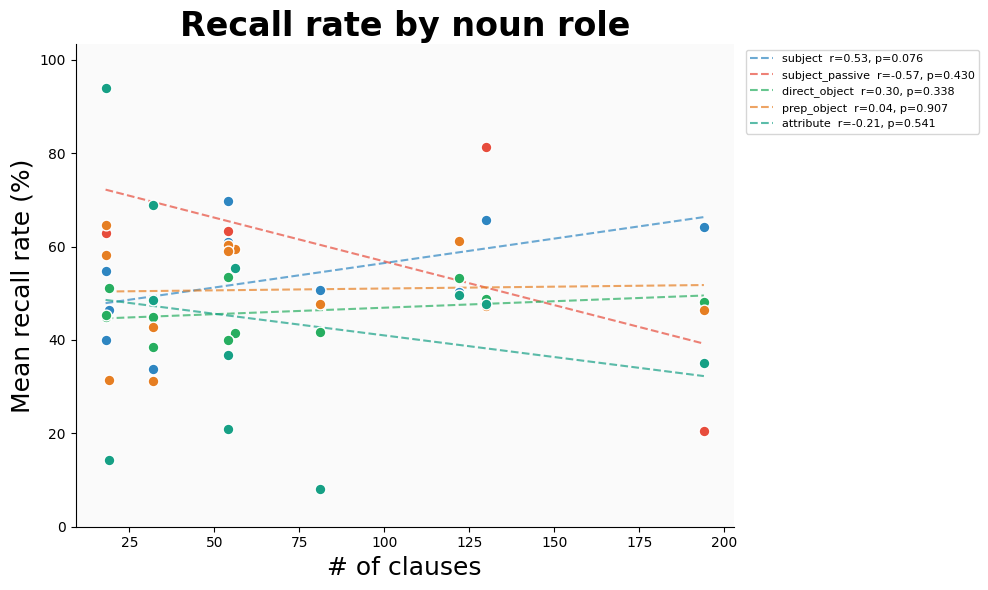

Source        F   p-unc     ng2
  role 1.202883 0.38044 0.30593
            A               B          T    p-unc   p-corr sig    hedges
    attribute   direct_object  -1.609121 0.248867 1.000000  ns -0.788233
    attribute     prep_object  -1.651348 0.240464 1.000000  ns -1.248648
    attribute         subject  -7.437263 0.017603 0.176030  ns -3.735856
    attribute subject_passive  -1.006686 0.420085 1.000000  ns -0.536849
direct_object     prep_object  -0.774935 0.519454 1.000000  ns -0.694808
direct_object         subject -12.090800 0.006771 0.067711  ns -3.794541
direct_object subject_passive  -0.503015 0.664882 1.000000  ns -0.335983
  prep_object         subject  -2.120289 0.168074 1.000000  ns -1.705037
  prep_object subject_passive  -0.217250 0.848162 1.000000  ns -0.132195
      subject subject_passive   0.474044 0.682180 1.000000  ns  0.307683


In [9]:
from scipy import stats
clauses = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]

import pingouin as pg
import pandas as pd

clause_arr  = np.array(clauses[0:12])
role_colors = ['#2e86c1','#e74c3c','#27ae60','#8e44ad','#e67e22','#16a085']

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#fafafa')

all_vals = []
for role in roles:
    rate_arr = np.array(recall_rate_by_role[role])
    all_vals.extend(rate_arr[~np.isnan(rate_arr)])
y_max = max(all_vals) * 1.1

for role, color in zip(roles, role_colors):
    rate_arr = np.array(recall_rate_by_role[role])
    valid    = ~np.isnan(rate_arr)
    if valid.sum() < 2:
        continue
    slope, intercept, r, p_val, _ = stats.linregress(clause_arr[valid], rate_arr[valid])

    ax.scatter(clause_arr[valid], rate_arr[valid], color=color, s=60,
               edgecolors='white', linewidths=1, zorder=5)
    x_line = np.linspace(clause_arr[valid].min(), clause_arr[valid].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, '--', color=color, lw=1.5,
            alpha=0.7, label=f'{role}  r={r:.2f}, p={p_val:.3f}')

ax.set_xlabel('# of clauses', fontsize=18)
ax.set_ylabel('Mean recall rate (%)', fontsize=18)
ax.set_title('Recall rate by noun role', fontsize=24, fontweight='bold')
ax.set_ylim([0, y_max])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('recall_by_noun_role.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── repeated measures ANOVA across noun roles ─────────────────────────────────
df_rows = []
for s in range(12):
    for role in roles:
        val = recall_rate_by_role[role][s]
        if not np.isnan(val):
            df_rows.append({'story': s, 'role': role, 'recall': val})

df = pd.DataFrame(df_rows)
aov = pg.rm_anova(data=df, dv='recall', within='role', subject='story')
print(aov[['Source', 'F', 'p-unc', 'ng2']].to_string(index=False))

# post-hoc pairwise t-tests
posthoc = pg.pairwise_tests(data=df, dv='recall', within='role',
                             subject='story', padjust='bonf',
                             effsize='hedges')

def add_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

posthoc['sig'] = posthoc['p-corr'].apply(add_stars)
print(posthoc[['A', 'B', 'T', 'p-unc', 'p-corr', 'sig', 'hedges']].to_string(index=False))



## Other phrases not noun.

In [10]:
from nltk import RegexpParser

# ── phrase type definitions ───────────────────────────────────────────────────
PHRASE_CONFIGS = {
    'vp':        ("VP",        "VP: {<VB.*><RP>?}"),
    'jp':        ("JP",        "JP: {<RB.*>*<JJ.*>+}"),
    'pp':        ("PP",        "PP: {<IN><DT>?<JJ.*>*<NN.*>}"),
    'adp':       ("ADP",       "ADP: {<RB.*>*<JJ.*>?<RB.*>}"),
    'vn':        ("VN",        "VN: {<VBG><DT>?<JJ.*>*<NN.*>+}"),
    'ad_clause': ("AD_clause", "AD_clause: {<IN|WRB><.*>*}"),
    'i_clause':  ("I_clause",  "I_clause: {<TO><VB><DT>?<NN.*>+}"),
}

# ── generic extractor ─────────────────────────────────────────────────────────
def find_phrases(tagged_input, label, grammar):
    parser = RegexpParser(grammar)
    trees  = [parser.parse(s) for s in tagged_input]
    return [sub for tree in trees for sub in tree.subtrees() if sub.label() == label]

# ── extract all phrase types ──────────────────────────────────────────────────
phrase_all        = {}
phrase_recall_all = {}

for key, (label, grammar) in PHRASE_CONFIGS.items():
    phrase_all[key]        = [find_phrases(t, label, grammar) for t in tagged_all]
    phrase_recall_all[key] = [[find_phrases(r, label, grammar) for r in story]
                               for story in tagged_recall_all]
    print(f"{key} done")

# ── unpack into original variable names ──────────────────────────────────────
verb_all         = phrase_all['vp'];        verb_recall_all      = phrase_recall_all['vp']
adj_all          = phrase_all['jp'];        adj_recall_all       = phrase_recall_all['jp']
pp_all           = phrase_all['pp'];        pp_recall_all        = phrase_recall_all['pp']
adp_all          = phrase_all['adp'];       adp_recall_all       = phrase_recall_all['adp']
vn_all           = phrase_all['vn'];        vn_recall_all        = phrase_recall_all['vn']
ad_clause_all    = phrase_all['ad_clause']; ad_clause_recall_all = phrase_recall_all['ad_clause']
i_all            = phrase_all['i_clause'];  i_recall_all         = phrase_recall_all['i_clause']


vp done
jp done
pp done
adp done
vn done
ad_clause done
i_clause done


## Get the unique phrases from the narratives and the recalls. 

In [11]:
def clean_tree_np_vb(input_tree):
    combined_phrase = [" ".join(word for word, tag in np.leaves()) for np in input_tree]
    unique_list = []
    [unique_list.append(item) for item in combined_phrase if item not in unique_list]
    unique_list = [phrase for phrase in unique_list if phrase.lower() != "i"]  # remove "i" as a noun.
    return unique_list

def clean_tree_adj(input_tree):
    combined_phrase = [" ".join(word for word, tag in adj.leaves()) for adj in input_tree]
    unique_list = []
    [unique_list.append(item) for item in combined_phrase if item not in unique_list]
    unique_list = [phrase for phrase in unique_list if phrase.lower() != "i"]   # manually remove "i" as adj phrase for narrative and tag error above.
    return unique_list

cleaned_np_all = [clean_tree_np_vb(np) for np in noun_all]
cleaned_vb_all = [clean_tree_np_vb(vb) for vb in verb_all]
cleaned_adj_all = [clean_tree_adj(adj) for adj in adj_all]
cleaned_pp_all = [clean_tree_np_vb(np) for np in pp_all]
cleaned_adp_all = [clean_tree_np_vb(np) for np in adp_all]
cleaned_vn_all = [clean_tree_np_vb(np) for np in vn_all]
cleaned_ad_clause_all = [clean_tree_np_vb(np) for np in ad_clause_all]
cleaned_i_all = [clean_tree_np_vb(np) for np in i_all]

cleaned_np_recall_all = [[clean_tree_np_vb(recall) for recall in each_story] for each_story in noun_recall_all]
cleaned_vb_recall_all = [[clean_tree_np_vb(recall) for recall in each_story] for each_story in verb_recall_all]
cleaned_adj_recall_all = [[clean_tree_adj(recall) for recall in each_story] for each_story in adj_recall_all]
cleaned_pp_recall_all = [[clean_tree_np_vb(recall) for recall in each_story] for each_story in pp_recall_all]
cleaned_adp_recall_all = [[clean_tree_np_vb(recall) for recall in each_story] for each_story in adp_recall_all]
cleaned_vn_recall_all = [[clean_tree_np_vb(recall) for recall in each_story] for each_story in vn_recall_all]
cleaned_ad_clause_recall_all = [[clean_tree_np_vb(recall) for recall in each_story] for each_story in ad_clause_recall_all]
cleaned_i_recall_all = [[clean_tree_np_vb(recall) for recall in each_story] for each_story in i_recall_all]


## Get the embedding of the phrases to compare their distance.

In [12]:
## get the distance of recalled phrases with the story phrases.
def embedding_words_method2(input_df):         # good for capturing the sematic meanings of the text.
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embedding_vec = []
    for phrase in input_df:
        embeddings = model.encode(phrase)
        embedding_vec.append(embeddings)
    return embedding_vec

embedding_np_all = [embedding_words_method2(np) for np in cleaned_np_all]
print("story np embedding finished.")
embedding_vb_all = [embedding_words_method2(vb) for vb in cleaned_vb_all]
print("story vb embedding finished.")
embedding_adj_all = [embedding_words_method2(adj) for adj in cleaned_adj_all]
print("story adj embedding finished.")

embedding_pp_all = [embedding_words_method2(np) for np in cleaned_pp_all]
embedding_adp_all = [embedding_words_method2(np) for np in cleaned_adp_all]
embedding_vn_all = [embedding_words_method2(np) for np in cleaned_vn_all]
embedding_ad_clause_all = [embedding_words_method2(np) for np in cleaned_ad_clause_all]
embedding_i_all = [embedding_words_method2(np) for np in cleaned_i_all]


story np embedding finished.
story vb embedding finished.
story adj embedding finished.


In [13]:
embedding_np_recall_all = Parallel(n_jobs=7)(delayed(embedding_words_method2)(np_recall) for np_recall in cleaned_np_recall_all)
print("recalled np embedding finished.")
embedding_vb_recall_all = Parallel(n_jobs=7)(delayed(embedding_words_method2)(vb_recall) for vb_recall in cleaned_vb_recall_all)
print("recalled vb embedding finished.")
embedding_adj_recall_all = Parallel(n_jobs=7)(delayed(embedding_words_method2)(adj_recall) for adj_recall in cleaned_adj_recall_all)
print("recalled adj embedding finished.")

embedding_pp_recall_all = Parallel(n_jobs=7)(delayed(embedding_words_method2)(np_recall) for np_recall in cleaned_pp_recall_all)
embedding_adp_recall_all = Parallel(n_jobs=7)(delayed(embedding_words_method2)(np_recall) for np_recall in cleaned_adp_recall_all)
embedding_vn_recall_all = Parallel(n_jobs=7)(delayed(embedding_words_method2)(np_recall) for np_recall in cleaned_vn_recall_all)
embedding_ad_clause_recall_all = Parallel(n_jobs=7)(delayed(embedding_words_method2)(np_recall) for np_recall in cleaned_ad_clause_recall_all)
embedding_i_recall_all = Parallel(n_jobs=7)(delayed(embedding_words_method2)(np_recall) for np_recall in cleaned_i_recall_all)

recalled np embedding finished.
recalled vb embedding finished.
recalled adj embedding finished.


## Matching the recalled phrases with the narrative's phrases with a distance < 0.5.

In [14]:
def convert_degree_threshold(degree):
    th = 1 - math.cos(math.radians(degree))
    return th

distance_angle = 60
distance_threshold = convert_degree_threshold(distance_angle)  # cosine(75°).


## Recalculate the matching relation between the recalled embedding and the narrative embedding. 
def matching_phrases_np(index):
    recall_count = [0 for i in np.arange(len(embedding_np_recall_all[index]))]
    for embedding in embedding_np_all[index]:
        for participant in np.arange(len(embedding_np_recall_all[index])):
            for recall_embedding in embedding_np_recall_all[index][participant]:
                if cosine(embedding, recall_embedding) < distance_threshold:    # cosine distance < 0.5, angle < 60°.
                    recall_count[participant] += 1
                    break
    return recall_count

def matching_phrases_vb(index):
    recall_count = [0 for i in np.arange(len(embedding_vb_recall_all[index]))]
    for embedding in embedding_vb_all[index]:
        for participant in np.arange(len(embedding_vb_recall_all[index])):
            for recall_embedding in embedding_vb_recall_all[index][participant]:
                if cosine(embedding, recall_embedding) < distance_threshold:    # cosine distance < 0.5, angle < 60°.
                    recall_count[participant] += 1
                    break
    return recall_count

def matching_phrases_adj(index):
    recall_count = [0 for i in np.arange(len(embedding_adj_recall_all[index]))]
    for embedding in embedding_adj_all[index]:
        for participant in np.arange(len(embedding_adj_recall_all[index])):
            for recall_embedding in embedding_adj_recall_all[index][participant]:
                if cosine(embedding, recall_embedding) < distance_threshold:    # cosine distance < 0.5, angle < 60°.
                    recall_count[participant] += 1
                    break
    return recall_count


def matching_phrases(index, narrative_embedding, recall_embedding):
    recall_count = [0 for i in np.arange(len(recall_embedding[index]))]
    if len(narrative_embedding[index]) > 0:  ## all the embeddings for a story, in one phrase category.
        for embedding in narrative_embedding[index]:   ## this is each embedding for the phrases in the narrative.
            
            for participant in np.arange(len(recall_embedding[index])):
                if len(recall_embedding[index][participant]) > 1:  ## skip the empty recall strings, and keep the count = 0.
                    for indx, recall_embedding_each in enumerate(recall_embedding[index][participant]):   ## this is each embedding for phrases in each recall.
                        if cosine(embedding, recall_embedding_each) < distance_threshold:    # cosine distance < 0.5, angle < 60°.
                            recall_count[participant] += 1
                            break 
                elif len(recall_embedding[index][participant]) == 1:
                    if cosine(embedding, recall_embedding[index][participant][0]) < distance_threshold:    # cosine distance < 0.5, angle < 60°.
                        recall_count[participant] += 1
                        break      
        return recall_count
        
    else:
        return np.NaN
    

count_recalled_phrases_np = [matching_phrases_np(i) for i in np.arange(12)]
count_recalled_phrases_vb = [matching_phrases_vb(i) for i in np.arange(12)]
count_recalled_phrases_adj = [matching_phrases_adj(i) for i in np.arange(12)]
count_recalled_phrases_pp = [matching_phrases(i, embedding_pp_all, embedding_pp_recall_all) for i in np.arange(12)]
count_recalled_phrases_adp = [matching_phrases(i, embedding_adp_all, embedding_adp_recall_all) for i in np.arange(12)]
count_recalled_phrases_vn = [matching_phrases(i, embedding_vn_all, embedding_vn_recall_all) for i in np.arange(12)]
count_recalled_phrases_ad_clause = [matching_phrases(i, embedding_ad_clause_all, embedding_ad_clause_recall_all) for i in np.arange(12)]
count_recalled_phrases_i = [matching_phrases(i, embedding_i_all, embedding_i_recall_all) for i in np.arange(12)]

# print(count_recalled_phrases_np[0])

### Calculate the proportion of the narrative's phrases recalled.
total_phrases_np_story = [len(cleaned_np_all[story]) for story in np.arange(12)]
total_phrases_vb_story = [len(cleaned_vb_all[story]) for story in np.arange(12)]
total_phrases_adj_story = [len(cleaned_adj_all[story]) for story in np.arange(12)]
total_phrases_pp_story = [len(cleaned_pp_all[story]) for story in np.arange(12)]
total_phrases_adp_story = [len(cleaned_adp_all[story]) for story in np.arange(12)]
total_phrases_vn_story = [len(cleaned_vn_all[story]) for story in np.arange(12)]
total_phrases_ad_clause_story = [len(cleaned_ad_clause_all[story]) for story in np.arange(12)]
total_phrases_i_story = [len(cleaned_i_all[story]) for story in np.arange(12)]

clauses_story = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]   # clauses in each story by sequence.


In [15]:
import numpy as np
import math

# ── phrase type config: (count_list, total_list) ─────────────────────────────
phrase_types = {
    'np':        (count_recalled_phrases_np,        total_phrases_np_story),
    'vb':        (count_recalled_phrases_vb,        total_phrases_vb_story),
    'adj':       (count_recalled_phrases_adj,       total_phrases_adj_story),
    'pp':        (count_recalled_phrases_pp,        total_phrases_pp_story),
    'adp':       (count_recalled_phrases_adp,       total_phrases_adp_story),
    'vn':        (count_recalled_phrases_vn,        total_phrases_vn_story),
    'ad_clause': (count_recalled_phrases_ad_clause, total_phrases_ad_clause_story),
    'i':         (count_recalled_phrases_i,         total_phrases_i_story),
}

# ── compute mean and percentage per phrase type ───────────────────────────────
means       = {}
percentages = {}
x_vals      = {}
y_vals      = {}

for key, (counts, totals) in phrase_types.items():
    y = [np.mean(story) for story in counts]
    means[key]       = [100 * np.mean(story) / totals[i] for i, story in enumerate(counts)]
    x_vals[key]      = totals
    y_vals[key]      = y
    percentages[key] = [100 * y[i] / totals[i] for i in range(len(totals))]

# ── filter infinitive phrases (may contain NaN) ───────────────────────────────
x8_nonempty, y8_nonempty = zip(*[
    (x, y) for x, y in zip(x_vals['i'], y_vals['i'])
    if not math.isnan(y)
]) if any(not math.isnan(v) for v in y_vals['i']) else ([], [])

x8_nonempty  = list(x8_nonempty)
y8_nonempty  = list(y8_nonempty)
percentages['i'] = [100 * y8_nonempty[i] / x8_nonempty[i] for i in range(len(y8_nonempty))]

# ── unpack into original variable names ──────────────────────────────────────
x1, y1, mean_np,        y1_percentage = x_vals['np'],        y_vals['np'],        means['np'],        percentages['np']
x2, y2, mean_vb,        y2_percentage = x_vals['vb'],        y_vals['vb'],        means['vb'],        percentages['vb']
x3, y3, mean_adj,       y3_percentage = x_vals['adj'],       y_vals['adj'],       means['adj'],       percentages['adj']
x4, y4, mean_pp,        y4_percentage = x_vals['pp'],        y_vals['pp'],        means['pp'],        percentages['pp']
x5, y5, mean_adp,       y5_percentage = x_vals['adp'],       y_vals['adp'],       means['adp'],       percentages['adp']
x6, y6, mean_vn,        y6_percentage = x_vals['vn'],        y_vals['vn'],        means['vn'],        percentages['vn']
x7, y7, mean_ad_clause, y7_percentage = x_vals['ad_clause'], y_vals['ad_clause'], means['ad_clause'], percentages['ad_clause']
x8, y8, mean_i,         y8_percentage = x8_nonempty,         y8_nonempty,         means['i'],         percentages['i']

x_fit1 = np.linspace(0, 220, 220)
y_fit  = x_fit1


## Plot. 

In [16]:
## ── recompute per-participant recall % and SE, from participant-level counts ──
def per_participant_rate_and_se(count_recalled_phrases, total_phrases_story):
    """
    count_recalled_phrases[i] : per-participant RAW COUNT of matched phrases for story i
                                 (already indexed by participant, from matching_phrases_*)
    total_phrases_story[i]    : total number of phrases of this type in story i's narrative

    Converts each participant's count to a % of that story's total phrases,
    then returns the per-story mean and Fisher-information SE across participants.
    """
    means, ses = [], []
    for i in range(12):
        counts = count_recalled_phrases[i]
        total  = total_phrases_story[i]

        if isinstance(counts, float) and math.isnan(counts):   # matching_phrases() returned NaN
            means.append(np.nan)
            ses.append(np.nan)
            continue
        if total == 0 or len(counts) == 0:
            means.append(np.nan)
            ses.append(np.nan)
            continue

        participant_rates = [100 * c / total for c in counts]
        means.append(np.mean(participant_rates))
        if len(participant_rates) > 1:
            ses.append(np.std(participant_rates, ddof=1) / np.sqrt(len(participant_rates)))
        else:
            ses.append(np.nan)
    return means, ses


y1_percentage, y1_se = per_participant_rate_and_se(count_recalled_phrases_np,        total_phrases_np_story)
y2_percentage, y2_se = per_participant_rate_and_se(count_recalled_phrases_vb,        total_phrases_vb_story)
y3_percentage, y3_se = per_participant_rate_and_se(count_recalled_phrases_adj,       total_phrases_adj_story)
y4_percentage, y4_se = per_participant_rate_and_se(count_recalled_phrases_pp,        total_phrases_pp_story)
y5_percentage, y5_se = per_participant_rate_and_se(count_recalled_phrases_adp,       total_phrases_adp_story)
y6_percentage, y6_se = per_participant_rate_and_se(count_recalled_phrases_vn,        total_phrases_vn_story)
y7_percentage, y7_se = per_participant_rate_and_se(count_recalled_phrases_ad_clause, total_phrases_ad_clause_story)
y8_percentage, y8_se = per_participant_rate_and_se(count_recalled_phrases_i,         total_phrases_i_story)


Noun Phrases                    p = 0.8057
Verb Phrases                    p = 0.1722
'in, on, at...' Phrases         p = 0.0828
Adverb Phrases                  p = 0.0755
Adjective Phrases               p = 0.4760
'because, although...' Phrases  p = 0.4895
'doing' Phrases                 p = 0.5915
'To do' Phrases                 p = 0.4631


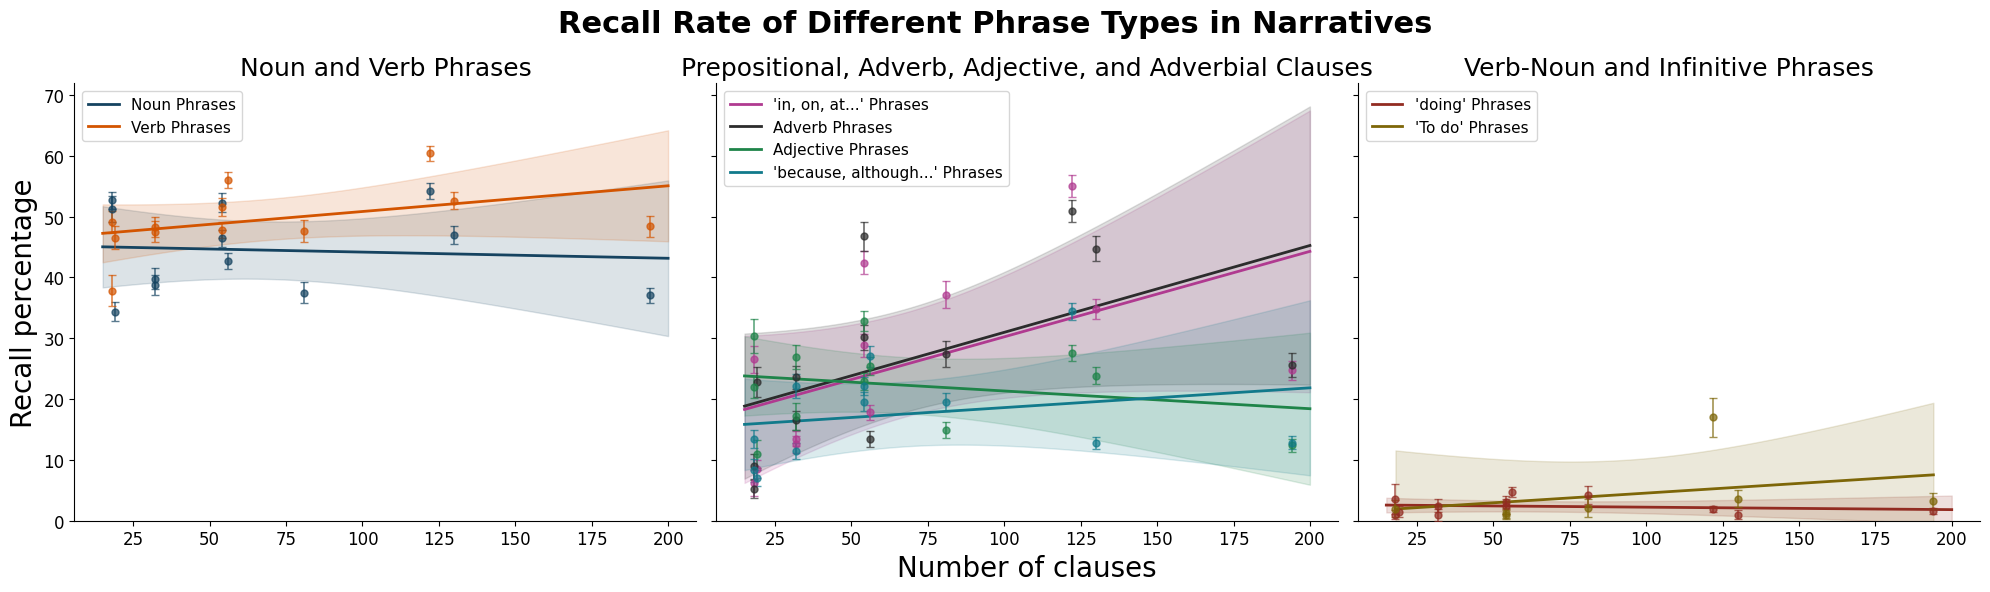

In [17]:
# darker color palette
colors = [
    '#154360',  # dark blue
    '#d35400',  # dark orange
    '#1e8449',  # dark green
    '#922b21',  # dark red
    '#117a8b',  # dark teal
    '#7d6608',  # dark olive
    '#b03a90',  # dark pink
    '#2c2c2c',  # dark gray
]

clause_story = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]

def plot_phrase(ax, x_data, y_data, yerr_data, color, label, x_fit):
    x_arr    = np.array(x_data)
    y_arr    = np.array(y_data)
    yerr_arr = np.array(yerr_data)

    X = sm.add_constant(x_arr)
    m = sm.OLS(y_arr, X).fit()
    iv, sl = m.params
    p      = m.pvalues[1]
    y_fit  = iv + sl * x_fit

    # regression confidence interval
    X_fit  = sm.add_constant(x_fit)
    pred   = m.get_prediction(X_fit)
    ci     = pred.conf_int(alpha=0.05)
    ci_lo  = ci[:, 0]
    ci_hi  = ci[:, 1]

    ax.errorbar(x_arr, y_arr, yerr=yerr_arr,
                fmt='o', color=color, ecolor=color, elinewidth=1.2,
                capsize=3, markersize=5, alpha=0.7, zorder=3)
    ax.plot(x_fit, y_fit, "-", color=color, linewidth=2,
            label=f"{label}")
    ax.fill_between(x_fit, ci_lo, ci_hi, color=color, alpha=0.15)
    print(f"{label:30s}  p = {p:.4f}")

x_fit = np.linspace(15, 200, 100)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# ── Figure 1: Noun and Verb phrases ──────────────────────────────────────────
plot_phrase(axes[0], clause_story, y1_percentage, y1_se, colors[0], "Noun Phrases", x_fit)
plot_phrase(axes[0], clause_story, y2_percentage, y2_se, colors[1], "Verb Phrases", x_fit)
axes[0].set_title("Noun and Verb Phrases", fontsize=18)

# ── Figure 2: PP, ADP, ADJ, AD_clauses ───────────────────────────────────────
plot_phrase(axes[1], clause_story, y4_percentage, y4_se, colors[6], "'in, on, at...' Phrases",        x_fit)
plot_phrase(axes[1], clause_story, y5_percentage, y5_se, colors[7], "Adverb Phrases",                 x_fit)
plot_phrase(axes[1], clause_story, y3_percentage, y3_se, colors[2], "Adjective Phrases",              x_fit)
plot_phrase(axes[1], clause_story, y7_percentage, y7_se, colors[4], "'because, although...' Phrases", x_fit)
axes[1].set_title("Prepositional, Adverb, Adjective, and Adverbial Clauses", fontsize=18)

# ── Figure 3: VN and IP ───────────────────────────────────────────────────────
clauses_ip, y8_clean, y8_se_clean = zip(*[
    (c, y, se) for c, y, se in zip(clause_story, y8_percentage, y8_se)
    if not math.isnan(y)
])
plot_phrase(axes[2], clause_story, y6_percentage, y6_se, colors[3], "'doing' Phrases", x_fit)
plot_phrase(axes[2], list(clauses_ip), list(y8_clean), list(y8_se_clean),
            colors[5], "'To do' Phrases",
            np.linspace(min(clauses_ip), max(clauses_ip), 100))
axes[2].set_title("Verb-Noun and Infinitive Phrases", fontsize=18)

# ── shared formatting ─────────────────────────────────────────────────────────
for ax in axes:
    ax.set_ylim(bottom=0)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, loc="upper left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Recall percentage", fontsize=20)
axes[1].set_xlabel("Number of clauses", fontsize=20)
fig.suptitle("Recall Rate of Different Phrase Types in Narratives", fontsize=22, fontweight='bold')
plt.tight_layout()
plt.show()


Stories with complete data: 12 / 12
  Noun Phrases             : mean=44.486, std=6.730
  Verb Phrases             : mean=49.455, std=5.279
  Adjective Phrases        : mean=22.271, std=6.733
  PP Phrases               : mean=25.485, std=13.866
  Adverb Phrases           : mean=25.906, std=13.476
  VN Phrases               : mean=2.442, std=1.230
  Adverbial Clauses        : mean=17.352, std=7.347

Repeated Measures ANOVA:
  F(6, 66) = 53.9582,  p = 1.4710e-23
  η²g = 0.7365  (large)
  Sphericity ε = 0.4108
  Power = 1.0000

Pairwise Wilcoxon (FDR-corrected):
  Pair                W    p_raw   p_corr      η²   power  sig
  --------------------------------------------------------------
  NP    vs VP         16   0.0771   0.0953   0.632   0.424  ns (large)
  NP    vs AdjP        0   0.0005   0.0007   1.000   0.937  *** (large)
  NP    vs PP          0   0.0005   0.0007   1.000   0.937  *** (large)
  NP    vs AdvP        0   0.0005   0.0007   1.000   0.937  *** (large)
  NP    vs VN      

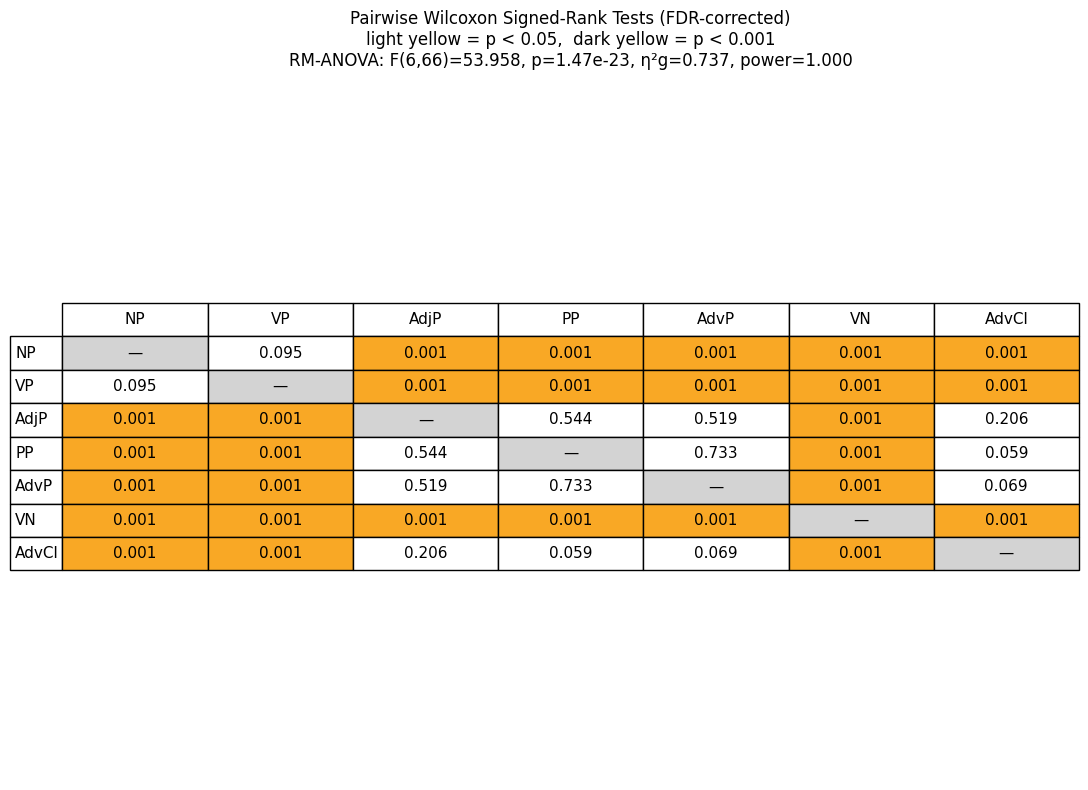

In [50]:
from scipy.stats import wilcoxon
from scipy.stats import norm as sp_norm
from scipy import stats as sp_stats
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import pingouin as pg

# ── collect data per phrase type ──
phrase_labels = [
    "Noun Phrases", "Verb Phrases", "Adjective Phrases", "PP Phrases",
    "Adverb Phrases", "VN Phrases", "Adverbial Clauses",
]
phrase_data_raw = [
    y1_percentage, y2_percentage, y3_percentage, y4_percentage,
    y5_percentage, y6_percentage, y7_percentage,
]
short_labels = ["NP", "VP", "AdjP", "PP", "AdvP", "VN", "AdvCl"]

# ── align data ──
n_stories = len(phrase_data_raw[0])
valid_idx  = [i for i in range(n_stories)
              if all(not math.isnan(d[i]) for d in phrase_data_raw)]
print(f"Stories with complete data: {len(valid_idx)} / {n_stories}")

phrase_data = [np.array([d[i] for i in valid_idx]) for d in phrase_data_raw]

for label, data in zip(phrase_labels, phrase_data):
    print(f"  {label:25s}: mean={np.mean(data):.3f}, std={np.std(data):.3f}")

# ── repeated measures ANOVA ──
n_valid = len(valid_idx)
df_long = pd.DataFrame({
    'story':     list(range(n_valid)) * len(phrase_labels),
    'condition': sum([[lbl]*n_valid for lbl in short_labels], []),
    'value':     sum([d.tolist() for d in phrase_data], [])
})

rm = pg.rm_anova(data=df_long, dv='value', within='condition',
                 subject='story', detailed=True)

F_stat  = rm.loc[rm['Source']=='condition', 'F'].values[0]
p_anova = rm.loc[rm['Source']=='condition', 'p-unc'].values[0]
ng2     = rm.loc[rm['Source']=='condition', 'ng2'].values[0]
eps_col = next((c for c in rm.columns if 'eps' in c.lower()), None)
eps     = rm.loc[rm['Source']=='condition', eps_col].values[0] if eps_col else float('nan')

df1_col = next((c for c in rm.columns if c.lower() in ('ddof1','df','df1','dof1')), None)
df2_col = next((c for c in rm.columns if c.lower() in ('ddof2','df2','dof2','df_error','dferror')), None)
df1 = float(rm.loc[rm['Source']=='condition', df1_col].values[0]) if df1_col else float(len(phrase_labels)-1)
df2 = None
if df2_col:
    v = rm.loc[rm['Source']=='condition', df2_col].values
    if len(v) and not np.isnan(float(v[0])):
        df2 = float(v[0])
if df2 is None:
    err_row = rm[rm['Source'].str.contains('error|within|residual', case=False, na=False)]
    if df2_col and len(err_row):
        v = err_row[df2_col].values
        if len(v) and not np.isnan(float(v[0])):
            df2 = float(v[0])
if df2 is None:
    df2 = (len(phrase_labels) - 1) * (n_valid - 1)

ncp         = F_stat * df1
f_crit      = sp_stats.f.ppf(0.95, df1, df2)
power_anova = 1 - sp_stats.ncf.cdf(f_crit, df1, df2, ncp)

print(f"\nRepeated Measures ANOVA:")
print(f"  F({int(df1)}, {int(df2)}) = {F_stat:.4f},  p = {p_anova:.4e}")
print(f"  η²g = {ng2:.4f}  ({'small' if ng2<0.06 else 'medium' if ng2<0.14 else 'large'})")
if not np.isnan(eps):
    print(f"  Sphericity ε = {eps:.4f}")
print(f"  Power = {power_anova:.4f}")

# ── pairwise Wilcoxon signed-rank tests ──
n = len(phrase_labels)
p_raw    = np.ones((n, n))
stat_mat = np.zeros((n, n))

pairs, raw_pvals, stats_w, effect_sizes, powers_ph = [], [], [], [], []

for i in range(n):
    for j in range(i+1, n):
        diff    = phrase_data[i] - phrase_data[j]
        diff_nz = diff[diff != 0]
        n_nz    = len(diff_nz)

        stat, p = wilcoxon(phrase_data[i], phrase_data[j])

        # rank-biserial r (bounded [-1,1]), η² = r²  (always in [0,1])
        r_rb   = 1 - (2 * stat) / (n_nz * (n_nz + 1)) if n_nz > 0 else 0.0
        eta_sq = r_rb**2

        # Z for power (clipped to avoid overflow)
        z_obs  = abs(sp_norm.ppf(max(min(p, 1 - 1e-10), 1e-10) / 2))
        z_crit = sp_norm.ppf(0.975)
        pwr    = 1 - sp_norm.cdf(z_crit - z_obs) + sp_norm.cdf(-z_crit - z_obs)

        p_raw[i, j] = p_raw[j, i] = p
        stat_mat[i, j] = stat_mat[j, i] = stat
        pairs.append((i, j))
        raw_pvals.append(p)
        stats_w.append(stat)
        effect_sizes.append(eta_sq)
        powers_ph.append(pwr)

reject, p_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method='fdr_bh')
p_matrix = np.ones((n, n))
for k, (i, j) in enumerate(pairs):
    p_matrix[i, j] = p_matrix[j, i] = p_corrected[k]

print(f"\nPairwise Wilcoxon (FDR-corrected):")
print(f"  {'Pair':<14} {'W':>6}  {'p_raw':>7}  {'p_corr':>7}  {'η²':>6}  {'power':>6}  sig")
print(f"  {'-'*62}")
for k, (i, j) in enumerate(pairs):
    sig = "***" if p_corrected[k] < 0.001 else "**" if p_corrected[k] < 0.01 \
          else "*"  if p_corrected[k] < 0.05 else "ns"
    eff_label = ('small'  if effect_sizes[k] < 0.06
                 else 'medium' if effect_sizes[k] < 0.14 else 'large')
    print(f"  {short_labels[i]:5s} vs {short_labels[j]:5s}  "
          f"{stats_w[k]:6.0f}  {raw_pvals[k]:7.4f}  {p_corrected[k]:7.4f}  "
          f"{effect_sizes[k]:6.3f}  {powers_ph[k]:6.3f}  {sig} ({eff_label})")

# ── plot table ──
fig, ax = plt.subplots(figsize=(11, 8))
ax.axis('off')

cell_text   = [[f"{p_matrix[i,j]:.3f}" if i != j else "—" for j in range(n)] for i in range(n)]
cell_colors = []
for i in range(n):
    row_colors = []
    for j in range(n):
        if i == j:
            row_colors.append('#d3d3d3')
        elif p_matrix[i, j] < 0.001:
            row_colors.append('#f9a825')
        elif p_matrix[i, j] < 0.05:
            row_colors.append('#fff176')
        else:
            row_colors.append('white')
    cell_colors.append(row_colors)

table = ax.table(
    cellText=cell_text,
    cellColours=cell_colors,
    rowLabels=short_labels,
    colLabels=short_labels,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

ax.set_title(
    f"Pairwise Wilcoxon Signed-Rank Tests (FDR-corrected)\n"
    f"light yellow = p < 0.05,  dark yellow = p < 0.001\n"
    f"RM-ANOVA: F({int(df1)},{int(df2)})={F_stat:.3f}, p={p_anova:.2e}, "
    f"η²g={ng2:.3f}, power={power_anova:.3f}",
    fontsize=12, pad=20
)

plt.tight_layout()
plt.savefig('wilcoxon_table.png', dpi=150, bbox_inches='tight')
plt.show()
